In [1]:
import pandas as pd

In [4]:
df = pd.read_excel('data.xlsx', sheet_name='Sheet1')

In [5]:
df.head()

,Date,Type,Quantity,Price
0,2025-06-01,Mongo,10,100
1,2025-06-02,Apple,20,120
2,2025-06-03,Banana,10,140
3,2025-06-04,Mango,15,200
4,2025-06-05,Apple,10,120


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Date      10 non-null     datetime64[ns]
 1   Type      10 non-null     object        
 2   Quantity  10 non-null     int64         
 3   Price     10 non-null     int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 452.0+ bytes


In [7]:
df['Quantity'].min()

np.int64(10)

In [9]:
k = df['Quantity'].mean()
k

np.float64(18.4)

In [10]:
df['Quantity']

0    10
1    20
2    10
3    15
4    10
5    52
6    12
7    10
8    33
9    12
Name: Quantity, dtype: int64

In [11]:
df[df['Quantity'] > k]

,Date,Type,Quantity,Price
1,2025-06-02,Apple,20,120
5,2025-06-06,Banana,52,214
8,2025-06-09,Orangle,33,42


In [13]:
df.loc[df['Quantity'] > k]

,Date,Type,Quantity,Price
1,2025-06-02,Apple,20,120
5,2025-06-06,Banana,52,214
8,2025-06-09,Orangle,33,42


In [15]:
df.loc[df['Quantity'] > k, ['Price', 'Quantity']]

,Price,Quantity
1,120,20
5,214,52
8,42,33


In [18]:
df.loc[df['Price'] < 50]

,Date,Type,Quantity,Price
7,2025-06-08,Banana,10,12
8,2025-06-09,Orangle,33,42
9,2025-06-10,Mango,12,12


In [20]:
df['Type'].unique()

array(['Mongo', 'Apple', 'Banana', 'Mango', 'Orangle'], dtype=object)

In [21]:
df['Quantity'].sum()

np.int64(184)

In [22]:
df['Amount'] = df['Price'] * df['Quantity']

In [23]:
df

,Date,Type,Quantity,Price,Amount
0,2025-06-01,Mongo,10,100,1000
1,2025-06-02,Apple,20,120,2400
2,2025-06-03,Banana,10,140,1400
3,2025-06-04,Mango,15,200,3000
4,2025-06-05,Apple,10,120,1200
5,2025-06-06,Banana,52,214,11128
6,2025-06-07,Apple,12,121,1452
7,2025-06-08,Banana,10,12,120
8,2025-06-09,Orangle,33,42,1386
9,2025-06-10,Mango,12,12,144


In [24]:
df = df.assign(Discouned = df['Amount'] * 0.9)  

In [28]:
df = df.assign(Class  = df['Amount'].apply(lambda x: 'High' if x > 1000 else 'Low'))

In [43]:
df1 = df.groupby(df['Type']).agg({'Quantity': 'sum', 'Amount': 'sum', 'Discouned': 'sum'})

In [45]:
df1

,Quantity,Amount,Discouned
Type,,,
Apple,42,5052,4546.8
Banana,72,12648,11383.2
Mango,27,3144,2829.6
Mongo,10,1000,900.0
Orangle,33,1386,1247.4


In [46]:
df1.Amount.sum()

np.int64(23230)

In [47]:
df1.sort_values(by = 'Amount', ascending=True)

,Quantity,Amount,Discouned
Type,,,
Mongo,10,1000,900.0
Orangle,33,1386,1247.4
Mango,27,3144,2829.6
Apple,42,5052,4546.8
Banana,72,12648,11383.2


In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
sns.set_theme(style="darkgrid")
df1.columns

Index(['Quantity', 'Amount', 'Discouned'], dtype='object')

C:\Users\DC\AppData\Local\Temp\ipykernel_4324\2701742885.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df1.index, y='Quantity', data=df1, palette='viridis')


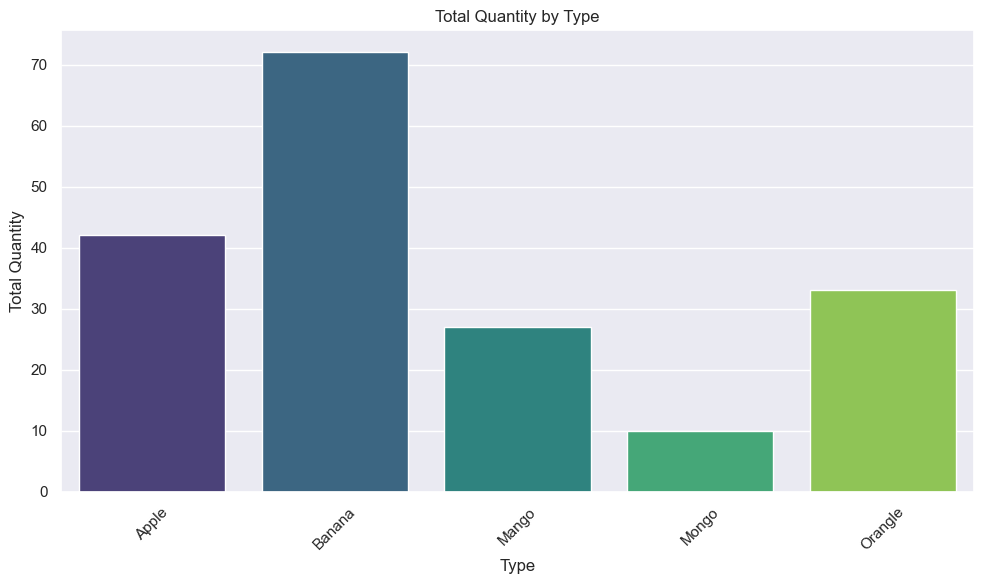

In [58]:
# Create a bar plot for the total amount by type
plt.figure(figsize=(10, 6))
sns.barplot(x=df1.index, y='Quantity', data=df1, palette='viridis')
plt.title('Total Quantity by Type')
plt.xlabel('Type')
plt.ylabel('Total Quantity')
plt.xticks(rotation=45)
plt.tight_layout()